In [34]:
# we will make a simple workflow llm using langgraph
#Start->question to llm->End

In [35]:
from langgraph.graph import StateGraph, START, END
from langchain_openai import AzureChatOpenAI,ChatOpenAI
from typing import TypedDict
from dotenv import load_dotenv
import os

In [36]:
load_dotenv()

True

In [37]:
gemini_api_key = os.getenv("GEMINI_API_KEY")
gemini_model = os.getenv("GEMINI_MODEL", "gemini-2.5-flash")

openai = ChatOpenAI(
    model=gemini_model,
    api_key=gemini_api_key,
    base_url="https://generativelanguage.googleapis.com/v1beta/openai",
)

In [38]:
# apikey = os.getenv("AZURE_OPENAI_API_KEY")
# endpoint = os.getenv("AZURE_OPENAI_API_ENDPOINT")
# apiversion = os.getenv("AZURE_OPENAI_API_VERSION")
# deployment = os.getenv("AZURE_OPENAI_DEPLOYMENT")

# azureopenai = AzureChatOpenAI(
#     azure_endpoint=endpoint,
#     api_key=apikey,
#     azure_deployment=deployment,
#     api_version=apiversion,
    
#     temperature=0.9,
#     max_tokens=2048,
#     timeout=60,
#     max_retries=2,
#     streaming=False,
#     validate_base_url=False,
#     disabled_params={"parallel_tool_calls": None},
# )

In [39]:
#define the state schema
class LLMState(TypedDict):
    question: str
    answer: str

In [40]:
def ask_question(state: LLMState) -> LLMState:
    # extract question from state
    question = state["question"]
    # make prompt
    prompt = f"Answer the following question: {question}"

    try:
        # ask llm
        # response = azureopenai.invoke(prompt)
        response = openai.invoke(prompt)
        # store answer in state
        state["answer"] = response.content
    except Exception as exc:
        state["answer"] = f"LLM request failed: {type(exc).__name__}: {exc}"

    return state

In [41]:
#define the graph
graph = StateGraph(LLMState)
#add nodes
graph.add_node("ask_question", ask_question)

#add edges
graph.add_edge(START, "ask_question")
graph.add_edge("ask_question", END)

#compile graph
workflow= graph.compile()


In [42]:
#execute graph
intial_state = {"question": "What is the capital of France?"}

finalstate= workflow.invoke(intial_state)

print(finalstate)

{'question': 'What is the capital of France?', 'answer': 'The capital of France is **Paris**.'}


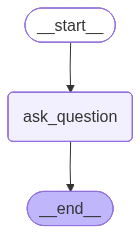

In [44]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())

In [45]:
openai.invoke("What is india?").content

AIMessage(content='India is a fascinating, complex, and vibrant country located in **South Asia**. It\'s many things at once, and its identity is shaped by a rich tapestry of geography, history, culture, and people.\n\nHere\'s a breakdown of what India is:\n\n1.  **A Sovereign Nation:**\n    *   **Capital:** New Delhi\n    *   **Government:** A federal parliamentary democratic republic. It is the **world\'s largest democracy**.\n    *   **Population:** The most populous country in the world (as of 2023), home to over 1.4 billion people.\n    *   **Area:** The seventh-largest country by land area, stretching from the Himalayas in the north to the Indian Ocean in the south.\n\n2.  **A Land of Immense Diversity:** This is perhaps India\'s most defining characteristic.\n    *   **Linguistic Diversity:** Over 22 official languages (including Hindi and English) and hundreds of other languages and dialects spoken across different regions.\n    *   **Religious Diversity:** The birthplace of Hi